# **# IMPORTING LIBRARIES**

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Market Basket Analysis
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# **# IMPORTING DATASET**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving part_2_market_basket_analysis.xlsx to part_2_market_basket_analysis.xlsx


In [5]:
df = pd.read_excel('part_2_market_basket_analysis.xlsx')

# **# UNDERSTANDING DATASET**

In [6]:
# Viewing first 5 rows
df.head()


,TransactionID,CustomerID,TransactionDate,ProductID,ProductName,Quantity,UnitPrice
0,TX200001,C10416,2025-06-04,MB009,Granola Bar,2,841
1,TX200002,C10782,2025-04-03,MB028,Notebook,1,743
2,TX200002,C10782,2025-04-03,MB030,Sticky Notes,1,568
3,TX200003,C10836,2025-03-23,MB001,Coffee Beans,1,775
4,TX200003,C10836,2025-03-23,MB002,Instant Coffee,2,249


In [7]:
# Shape of the dataset
df.shape

(4311, 7)

In [8]:
# Viewing column names
df.columns

Index(['TransactionID', 'CustomerID', 'TransactionDate', 'ProductID',
       'ProductName', 'Quantity', 'UnitPrice'],
      dtype='object')

In [9]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4311 entries, 0 to 4310
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    4311 non-null   object        
 1   CustomerID       4311 non-null   object        
 2   TransactionDate  4311 non-null   datetime64[ns]
 3   ProductID        4311 non-null   object        
 4   ProductName      4286 non-null   object        
 5   Quantity         4311 non-null   int64         
 6   UnitPrice        4311 non-null   int64         
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 235.9+ KB


In [10]:
# Statistical Summary
df.describe()

,TransactionDate,Quantity,UnitPrice
count,4311,4311.000000,4311.000000
mean,2025-04-04 03:53:09.144050176,1.413825,490.854790
min,2025-01-01 00:00:00,0.000000,84.000000
25%,2025-02-17 00:00:00,1.000000,283.000000
50%,2025-04-08 00:00:00,1.000000,459.000000
75%,2025-05-19 00:00:00,2.000000,728.000000
max,2025-06-30 00:00:00,4.000000,841.000000
std,NaN,0.762177,227.791302


# **# DATA CLEANING**

In [11]:
# Checking missing values
df.isnull().sum()

,0
TransactionID,0
CustomerID,0
TransactionDate,0
ProductID,0
ProductName,25
Quantity,0
UnitPrice,0


In [12]:
# Removing missing ProductName
df = df.dropna(subset=['ProductName'])

In [13]:
# Checking Duplicate count
df.duplicated().sum()

np.int64(25)

In [14]:
# Removing Duplicate Records
df = df.drop_duplicates()

In [16]:
# Removing Cancelled Transactions
df = df[~df['TransactionID'].astype(str).str.startswith('C')]

In [21]:
# checking for the quantity less than zero
df[df['Quantity'] < 0 ]

,TransactionID,CustomerID,TransactionDate,ProductID,ProductName,Quantity,UnitPrice


In [20]:
# Checking Datatypes
df.dtypes

,0
TransactionID,object
CustomerID,object
TransactionDate,datetime64[ns]
ProductID,object
ProductName,object
Quantity,int64
UnitPrice,int64


In [23]:
# Converting Datatype
df['TransactionID'] = df['TransactionID'].astype(str)
df['Quantity'] = df['Quantity'].astype(int)
df['UnitPrice'] = df['UnitPrice'].astype(float)


In [26]:
# Checking Rare or invalid products
print([df['ProductName'].value_counts()])

[ProductName
Granola Bar          261
Chocolate Spread     219
French Press         182
Coffee Beans         182
Butter               179
Instant Coffee       177
Salsa Dip            175
Bread Loaf           173
Fabric Softener      152
Baby Wipes           147
Conditioner          141
Nachos               136
Potato Chips         136
Oats Pack            135
Dishwash Liquid      133
Laundry Detergent    130
Shampoo              129
Body Wash            128
Pen Pack             126
Peanut Butter        125
Sticky Notes         119
Electrolyte Drink    118
Notebook             114
Green Tea            110
Black Tea            107
Honey Jar            107
Protein Bar          107
Almond Pack          105
Baby Lotion          104
Baby Diapers         104
Name: count, dtype: int64]


In [27]:
# Viewing Final Dataset Shape
df.shape

(4261, 7)

# **# TRANSACTION BASKET PREPARATION**

In [29]:
# Creating Basket Table
basket = (
    df.groupby(['TransactionID', 'ProductName'])['Quantity']
    .sum()
    .unstack()
    .fillna(0)
)

In [30]:
# Converting into Binary Values (0 and 1)
basket = basket.applymap(lambda x: 1 if x > 0 else 0)

In [31]:
# Viewing Basket
basket.head()

ProductName,Almond Pack,Baby Diapers,Baby Lotion,Baby Wipes,Black Tea,Body Wash,Bread Loaf,Butter,Chocolate Spread,Coffee Beans,Conditioner,Dishwash Liquid,Electrolyte Drink,Fabric Softener,French Press,Granola Bar,Green Tea,Honey Jar,Instant Coffee,Laundry Detergent,Nachos,Notebook,Oats Pack,Peanut Butter,Pen Pack,Potato Chips,Protein Bar,Salsa Dip,Shampoo,Sticky Notes
TransactionID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
TX200001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TX200002,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
TX200003,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0
TX200004,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TX200005,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0


**Transaction Basket Preparation:**
The raw transactional dataset is converted into basket format using grouping and pivot operations.

Steps performed:

1) Grouped data using Transaction ID and Product Name.
2) Summed quantities of products purchased in each transaction.
3) Converted rows into basket format where:
      - Rows represent transactions
      - Columns represent products
4) Converted quantity values into binary values:
      - 1 = Product purchased
      - 0 = Product not purchased

This format is required for Apriori and FP-Growth algorithms

# **Frequent Itemset Generation using Apriori Algorithm**

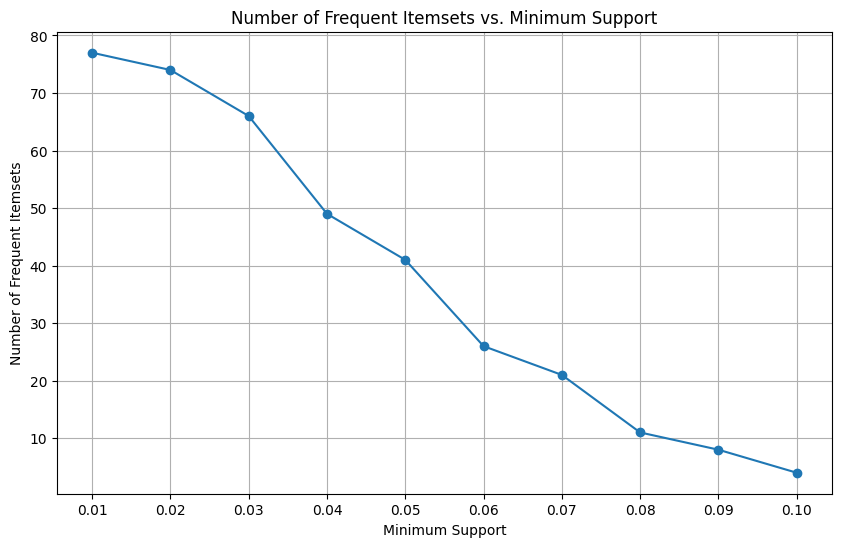

In [34]:
support_values = np.arange(0.01, 0.11, 0.01)
num_itemsets = []

for support in support_values:
    frequent_itemsets = apriori(basket, min_support=support, use_colnames=True)
    num_itemsets.append(len(frequent_itemsets))

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(support_values, num_itemsets, marker='o')
plt.title('Number of Frequent Itemsets vs. Minimum Support')
plt.xlabel('Minimum Support')
plt.ylabel('Number of Frequent Itemsets')
plt.grid(True)
plt.xticks(support_values)
plt.show()

From the plot, we can observe that as the minimum support increases, the number of frequent itemsets decreases. A min_support of 0.05 appears to be a reasonable starting point, as it still yields a good number of itemsets without being overly sparse or too dense. Let's proceed with this value.

In [43]:
# Choosing a reasonable support value and generating frequent itemsets
min_support_chosen = 0.05
frequent_itemsets = apriori(basket, min_support=min_support_chosen, use_colnames=True)

print(f"\nFrequent Itemsets generated with min_support = {min_support_chosen}:")
display(frequent_itemsets.sort_values(by='support', ascending=False).head(10))
print(f"Total frequent itemsets: {len(frequent_itemsets)}")


Frequent Itemsets generated with min_support = 0.05:


,support,itemsets
15,0.143969,(Granola Bar)
8,0.120067,(Chocolate Spread)
9,0.100056,(Coffee Beans)
14,0.100056,(French Press)
7,0.098388,(Butter)
27,0.097276,(Salsa Dip)
18,0.096165,(Instant Coffee)
6,0.094497,(Bread Loaf)
13,0.083936,(Fabric Softener)
32,0.081156,"(Chocolate Spread, Butter)"


Total frequent itemsets: 41


# **# ASSOCIATION RULE GENERATION**

Now that we have our frequent itemsets, we can generate association rules from them. We will set a minimum confidence threshold(0.6)to filter out less reliable rules.

In [47]:
# Generating association rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

print("Generated Association Rules (min_confidence = 0.6):")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(by='confidence', ascending=False))

Generated Association Rules (min_confidence = 0.6):


,antecedents,consequents,support,confidence,lift
11,"(Bread Loaf, Butter)",(Chocolate Spread),0.051140,0.867925,7.228686
4,(Butter),(Chocolate Spread),0.081156,0.824859,6.870004
2,(Bread Loaf),(Chocolate Spread),0.077821,0.823529,6.858932
7,(Nachos),(Salsa Dip),0.057810,0.770370,7.919407
8,(Potato Chips),(Salsa Dip),0.054475,0.731343,7.518209
6,(Dishwash Liquid),(Fabric Softener),0.052251,0.717557,8.548911
3,(Chocolate Spread),(Butter),0.081156,0.675926,6.870004
9,"(Chocolate Spread, Bread Loaf)",(Butter),0.051140,0.657143,6.679096
1,(Chocolate Spread),(Bread Loaf),0.077821,0.648148,6.858932
10,"(Chocolate Spread, Butter)",(Bread Loaf),0.051140,0.630137,6.668332


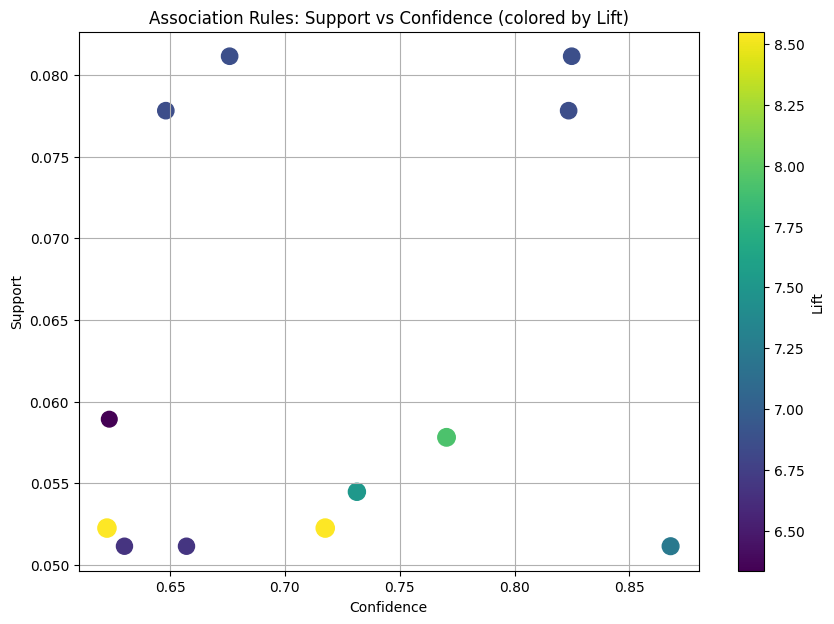

In [49]:
plt.figure(figsize=(10, 7))
plt.scatter(rules['confidence'], rules['support'], c=rules['lift'], cmap='viridis', s=rules['lift']*20) # s for size based on lift
plt.colorbar(label='Lift')
plt.xlabel('Confidence')
plt.ylabel('Support')
plt.title('Association Rules: Support vs Confidence (colored by Lift)')
plt.grid(True)
plt.show()

# **# RULE FILTERING AND INTERPRETATION**

To focus on the most meaningful relationships, we will filter the generated association rules based on the following criteria:
*   **Lift > 1**: Ensures a positive correlation between the antecedent and consequent.
*   **Confidence >= 0.6**: To ensure a reasonable level of predictability (already applied during generation).
*   **Support >= 0.05**: To ensure the itemsets are frequent enough (already applied during frequent itemset generation).


In [54]:
filtered_rules = rules[(rules['lift'] > 1)].sort_values(by=['lift', 'confidence'], ascending=[False, False])

print("Filtered Association Rules (Lift > 1, sorted by Lift and Confidence):")
display(filtered_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Filtered Association Rules (Lift > 1, sorted by Lift and Confidence):


,antecedents,consequents,support,confidence,lift
6,(Dishwash Liquid),(Fabric Softener),0.052251,0.717557,8.548911
5,(Fabric Softener),(Dishwash Liquid),0.052251,0.622517,8.548911
7,(Nachos),(Salsa Dip),0.057810,0.770370,7.919407
8,(Potato Chips),(Salsa Dip),0.054475,0.731343,7.518209
11,"(Bread Loaf, Butter)",(Chocolate Spread),0.051140,0.867925,7.228686
4,(Butter),(Chocolate Spread),0.081156,0.824859,6.870004
3,(Chocolate Spread),(Butter),0.081156,0.675926,6.870004
2,(Bread Loaf),(Chocolate Spread),0.077821,0.823529,6.858932
1,(Chocolate Spread),(Bread Loaf),0.077821,0.648148,6.858932
9,"(Chocolate Spread, Bread Loaf)",(Butter),0.051140,0.657143,6.679096


# **Interpretation of the 10 Association Rules**
**1. Dishwash Liquid → Fabric Softener**

Support: 0.052251

Confidence: 0.717557

Lift: 8.548911

**Business Meaning:**
About 5.2% of all transactions contain both Dishwash Liquid and Fabric Softener. Customers who buy Dishwash Liquid also buy Fabric Softener around 71.8% of the time. The very high lift value (8.55) shows a very strong relationship between these two products compared to random purchasing behavior.


**2. Fabric Softener → Dishwash Liquid**

Support: 0.052251

Confidence: 0.622517

Lift: 8.548911

**Business Meaning:**
Customers purchasing Fabric Softener also purchase Dishwash Liquid about 62.3% of the time. The lift value indicates these products are highly associated and are frequently purchased together more than expected.


**3. Nachos → Salsa Dip**

Support: 0.057810

Confidence: 0.770370

Lift: 7.919407

**Business Meaning:**
Approximately 5.8% of transactions contain both Nachos and Salsa Dip. Customers who buy Nachos purchase Salsa Dip 77% of the time. This strong lift value suggests that Nachos and Salsa Dip are complementary products and should be promoted together.


**4. Potato Chips → Salsa Dip**

Support: 0.054475

Confidence: 0.731343

Lift: 7.518209

**Business Meaning:**
About 5.4% of all purchases include both Potato Chips and Salsa Dip. Customers buying Potato Chips also buy Salsa Dip around 73.1% of the time. The high lift indicates a strong product association useful for combo offers and shelf placement.


**5. Butter, Bread Loaf → Chocolate Spread**

Support: 0.051140

Confidence: 0.867925

Lift: 7.228686

**Business Meaning:**
Customers purchasing both Butter and Bread Loaf also purchase Chocolate Spread about 86.8% of the time. This is one of the strongest confidence values in the dataset, showing a strong breakfast-related buying pattern.


**6. Butter → Chocolate Spread**

Support: 0.081156

Confidence: 0.824859

Lift: 6.870004

**Business Meaning:**
Around 8.1% of transactions include both Butter and Chocolate Spread. Customers buying Butter purchase Chocolate Spread approximately 82.5% of the time. The high lift value indicates these items are strongly connected in customer baskets.


**7. Chocolate Spread → Butter**

Support: 0.081156

Confidence: 0.675926

Lift: 6.870004

**Business Meaning:**
Customers who purchase Chocolate Spread also buy Butter about 67.6% of the time. The strong lift value confirms a significant association between these breakfast-related products.


**8. Bread Loaf → Chocolate Spread**

Support: 0.077821

Confidence: 0.823529

Lift: 6.858932

**Business Meaning:**
Approximately 7.8% of transactions contain both Bread Loaf and Chocolate Spread. Customers purchasing Bread Loaf buy Chocolate Spread around 82.4% of the time. This suggests these products are commonly consumed together.


**9. Chocolate Spread → Bread Loaf**

Support: 0.077821

Confidence: 0.648148

Lift: 6.858932

**Business Meaning:**
Customers who buy Chocolate Spread also purchase Bread Loaf about 64.8% of the time. The high lift value shows a strong relationship between these products and highlights a common pairing pattern.


**10. Chocolate Spread, Bread Loaf → Butter**

Support: 0.051140

Confidence: 0.657143

Lift: 6.679096

**Business Meaning:**
About 5.1% of all transactions include Chocolate Spread, Bread Loaf, and Butter together. Customers purchasing Chocolate Spread and Bread Loaf also buy Butter around 65.7% of the time. This rule identifies a strong three-product combination frequently bought together.